In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression

import timm
from transformers import ViTForImageClassification

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS = 3
IMG_SIZE = 224

MODEL_NAMES = {
    0: "Real",
    1: "SD2.1",
    2: "SDXL",
    3: "SD3",
    4: "DALL·E 3",
    5: "Midjourney"
}

In [3]:
ds = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset", split="train[:1000]")

df = pd.DataFrame({
    "image": ds["Image"],
    "label": ds["Label_A"],
    "model": ds["Label_B"],
    "Caption": ds["Caption"]
})

df["model_name"] = df["model"].map(MODEL_NAMES)
df.head()

,image,label,model,Caption,model_name
0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,0,0,Two tall giraffe standing next to each other o...,Real
1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1,1,Two tall giraffe standing next to each other o...,SD2.1
2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1,2,Two tall giraffe standing next to each other o...,SDXL
3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1,3,Two tall giraffe standing next to each other o...,SD3
4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1,4,Two tall giraffe standing next to each other o...,DALL·E 3


In [4]:
from sklearn.model_selection import GroupShuffleSplit

# ---------------------------
# split one train and test
# ---------------------------
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)

train_idx, temp_idx = next(gss1.split(df, groups=df["Caption"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# ---------------------------
# split two test and val
# ---------------------------
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)

val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["Caption"]))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# ---------------------------
# check that captions are all different
# ---------------------------
assert set(train_df["Caption"]).isdisjoint(set(val_df["Caption"]))
assert set(train_df["Caption"]).isdisjoint(set(test_df["Caption"]))
assert set(val_df["Caption"]).isdisjoint(set(test_df["Caption"]))

print(len(train_df), len(val_df), len(test_df))

696 150 154


In [5]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        # Store dataframe and reset index to ensure clean sequential indexing
        self.df = dataframe.reset_index(drop=True)
        
        # Image transformation pipeline (resize, tensor conversion, normalization, etc.)
        self.transform = transform

    def __len__(self):
        # Return total number of samples in the dataset
        return len(self.df)

    def __getitem__(self, idx):
        # Retrieve image and label at the given index
        img = self.df.loc[idx, "image"]
        label = self.df.loc[idx, "label"]

        # Convert numpy array to PIL image if needed
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        # Apply transformations to the image
        img = self.transform(img)

        # Return image tensor and label tensor (required for PyTorch training)
        return img, torch.tensor(label, dtype=torch.long)

In [6]:
# Define image preprocessing pipeline
transform = transforms.Compose([
    # Resize all images to a fixed size required by CNN/ViT models
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    
    # Convert PIL image to PyTorch tensor and scale pixel values to [0, 1]
    transforms.ToTensor(),
])

# Create DataLoader for training set
# shuffle=True ensures data is randomly mixed each epoch for better generalization
train_loader = DataLoader(
    ImageDataset(train_df, transform),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation loader (no shuffling needed for consistent evaluation)
val_loader = DataLoader(
    ImageDataset(val_df, transform),
    batch_size=BATCH_SIZE
)

# Test loader (final evaluation set, no shuffling to keep predictions aligned)
test_loader = DataLoader(
    ImageDataset(test_df, transform),
    batch_size=BATCH_SIZE
)

In [7]:
# Load pretrained EfficientNet-B4 model from timm library
# num_classes=2 because this is a binary classification task (real vs AI)
cnn_model = timm.create_model("efficientnet_b4", pretrained=True, num_classes=2)

# Move model to GPU if available, otherwise CPU
cnn_model = cnn_model.to(DEVICE)

In [8]:
# Load pretrained VIT model
# num_classes=2 because this is a binary classification task (real vs AI)
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Move model to GPU if available, otherwise CPU
vit_model = vit_model.to(DEVICE)

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [9]:
def train_model(model, loader, optimizer):
    # Set model to training mode (enables dropout, batchnorm updates, etc.)
    model.train()
    
    total_loss = 0

    # Iterate over batches of images and labels
    for images, labels in tqdm(loader):
        # Move data to the same device as the model (GPU/CPU)
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Reset gradients from previous step
        optimizer.zero_grad()

        # Forward pass: compute model outputs
        outputs = model(images)

        # Handle different model output formats (some return dict-like objects)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs

        # Compute classification loss (CrossEntropy for multi-class / binary classification)
        loss = nn.CrossEntropyLoss()(logits, labels)

        # Backpropagation: compute gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Accumulate loss for reporting
        total_loss += loss.item()

    # Return average loss per batch for this epoch
    return total_loss / len(loader)

In [10]:
# Define separate optimizers for CNN (EfficientNet) and ViT models
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-4)
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=1e-4)

# ---------------------------
# TRAINING LOOP
# ---------------------------
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")

    # Train CNN model for one epoch
    cnn_loss = train_model(cnn_model, train_loader, cnn_optimizer)
    print("CNN Loss:", cnn_loss)

    # Train Vision Transformer model for one epoch
    vit_loss = train_model(vit_model, train_loader, vit_optimizer)
    print("ViT Loss:", vit_loss)



Epoch 1


100%|██████████| 44/44 [02:51<00:00,  3.91s/it]


CNN Loss: 0.8095051944255829


100%|██████████| 44/44 [07:14<00:00,  9.87s/it]


ViT Loss: 0.4486895984208042

Epoch 2


...

ViT Loss: 0.11610640081661669

Epoch 3


100%|██████████| 44/44 [02:52<00:00,  3.92s/it]


CNN Loss: 0.1494281582364982


100%|██████████| 44/44 [07:14<00:00,  9.87s/it]

ViT Loss: 0.021714554162992335


In [11]:
# ---------------------------
# PREDICTION FUNCTION
# ---------------------------
def get_predictions(model, loader):
    # Set model to evaluation mode (disables dropout, etc.)
    model.eval()
    
    all_probs = []
    all_labels = []

    # Disable gradient computation for inference
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)

            # Forward pass
            outputs = model(images)

            # Handle different output formats (HuggingFace vs timm)
            logits = outputs.logits if hasattr(outputs, "logits") else outputs

            # Convert logits to probabilities using softmax
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            all_probs.append(probs)

            # Store ground-truth labels for evaluation
            all_labels.extend(labels.numpy())

    # Stack batch predictions into single array
    return np.vstack(all_probs), np.array(all_labels)


# ---------------------------
# VALIDATION PREDICTIONS (for stacking)
# ---------------------------
cnn_val, y_val = get_predictions(cnn_model, val_loader)
vit_val, _ = get_predictions(vit_model, val_loader)

# Combine CNN + ViT probabilities into meta-features
X_meta = np.hstack([cnn_val, vit_val])

# Train stacking (meta) model on validation predictions
meta_model = LogisticRegression()
meta_model.fit(X_meta, y_val)

LogisticRegression()

Accuracy: 0.9025974025974026
F1: 0.9442379182156133
ROC-AUC: 0.9251802884615385


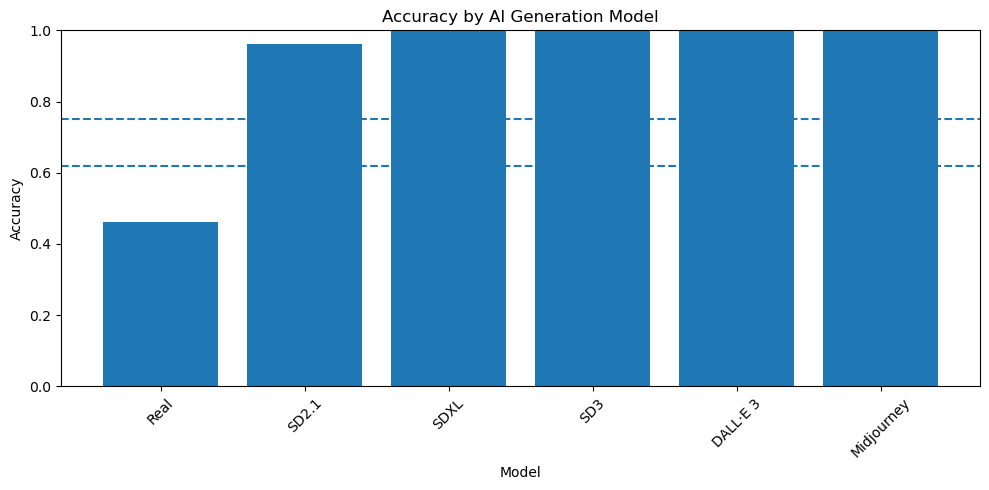

In [25]:
# ---------------------------
# TEST PREDICTIONS (final evaluation)
# ---------------------------
cnn_test, y_test = get_predictions(cnn_model, test_loader)
vit_test, _ = get_predictions(vit_model, test_loader)

# Build test-time meta-features
X_test_meta = np.hstack([cnn_test, vit_test])

# Final ensemble predictions
final_preds = meta_model.predict(X_test_meta)
final_probs = meta_model.predict_proba(X_test_meta)[:, 1]


# ---------------------------
# EVALUATION METRICS
# ---------------------------
print("Accuracy:", accuracy_score(y_test, final_preds))
print("F1:", f1_score(y_test, final_preds))
print("ROC-AUC:", roc_auc_score(y_test, final_probs))


import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ---------------------------
# PER-MODEL ACCURACY
# ---------------------------
test_df = test_df.reset_index(drop=True)
test_df["pred"] = final_preds

model_names = test_df["model_name"].unique()
model_accs = []

for m in model_names:
    subset = test_df[test_df["model_name"] == m]
    acc = accuracy_score(subset["label"], subset["pred"])
    model_accs.append(acc)

# ---------------------------
# PLOT
# ---------------------------
plt.figure(figsize=(10, 5))

plt.bar(model_names, model_accs)

# reference lines
plt.axhline(0.62, linestyle="--")
plt.axhline(0.75, linestyle="--")

plt.ylim(0, 1)

plt.title("Accuracy by AI Generation Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()